In [1]:
!pip install fmiopendata holidays lightgbm --quiet

import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta, timezone

# Global config
START_DATE = "2022-01-01"
END_DATE   = "2026-06-10"
TZ = "Europe/Helsinki"

  Preparing metadata (setup.py) ... done


In [2]:
def fetch_elering_prices(start: str, end: str) -> pd.DataFrame:
    """Fetch Nord Pool FI day-ahead prices from Elering's open API."""
    start_dt = pd.Timestamp(start, tz="UTC")
    end_dt   = pd.Timestamp(end, tz="UTC")
    frames = []

    chunk_start = start_dt
    while chunk_start < end_dt:
        chunk_end = min(chunk_start + pd.Timedelta(days=90), end_dt)
        url = "https://dashboard.elering.ee/api/nps/price"
        params = {
            "start": chunk_start.strftime("%Y-%m-%dT%H:%M:%S.000Z"),
            "end":   chunk_end.strftime("%Y-%m-%dT%H:%M:%S.000Z"),
        }
        resp = requests.get(url, params=params, timeout=30)
        resp.raise_for_status()
        data = resp.json()["data"]["fi"]
        frames.append(pd.DataFrame(data))
        chunk_start = chunk_end

    df = pd.concat(frames, ignore_index=True)
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s", utc=True)
    df = df.drop_duplicates("timestamp").sort_values("timestamp")
    df = df.set_index("timestamp").rename(columns={"price": "price_eur_mwh"})
    return df[["price_eur_mwh"]]

prices = fetch_elering_prices(START_DATE, END_DATE)
print(prices.shape)
prices.head()

(57055, 1)


,price_eur_mwh
timestamp,
2022-01-01 00:00:00+00:00,41.33
2022-01-01 01:00:00+00:00,42.18
2022-01-01 02:00:00+00:00,44.37
2022-01-01 03:00:00+00:00,37.67
2022-01-01 04:00:00+00:00,39.70


In [3]:
# Nord Pool moved to 15-minute resolution in late 2025, so recent data
# may be sub-hourly. Resampling everything to hourly means for consistency.
prices_hourly = prices.resample("1h").mean()

# Sanity checks
print("Range:", prices_hourly.index.min(), "→", prices_hourly.index.max())
print("Missing hours:", prices_hourly["price_eur_mwh"].isna().sum())
print(prices_hourly.describe())

prices_hourly.to_parquet("prices_fi_hourly.parquet")

Range: 2022-01-01 00:00:00+00:00 → 2026-06-10 00:00:00+00:00
Missing hours: 0
       price_eur_mwh
count   38905.000000
mean       74.300820
std        94.713686
min      -500.000000
25%        11.512500
50%        42.880000
75%       103.050000
max      1896.000000


In [4]:
import time
from fmiopendata.wfs import download_stored_query

def fetch_fmi_temps(place: str, start: str, end: str, chunk_days: int = 28) -> pd.Series:
    """Fetch hourly air temperature for a place from FMI open data."""
    start_dt = pd.Timestamp(start, tz="UTC")
    end_dt   = pd.Timestamp(end, tz="UTC")
    records = []

    chunk_start = start_dt
    n_chunks = int(np.ceil((end_dt - start_dt) / pd.Timedelta(days=chunk_days)))
    i = 0
    while chunk_start < end_dt:
        chunk_end = min(chunk_start + pd.Timedelta(days=chunk_days), end_dt)
        obs = download_stored_query(
            "fmi::observations::weather::hourly::multipointcoverage",
            args=[
                f"place={place}",
                "starttime=" + chunk_start.strftime("%Y-%m-%dT%H:%M:%SZ"),
                "endtime="   + chunk_end.strftime("%Y-%m-%dT%H:%M:%SZ"),
            ],
        )
        for t, stations in obs.data.items():
            for station_name, params in stations.items():
                for key, val in params.items():
                    if "temperature" in key.lower():
                        records.append((t, val["value"]))
                        break
        i += 1
        if i % 10 == 0:
            print(f"{place}: {i}/{n_chunks} chunks")
        time.sleep(0.2)  # being polite to the API
        chunk_start = chunk_end

    s = pd.DataFrame(records, columns=["time", "temp"]).drop_duplicates("time")
    s["time"] = pd.to_datetime(s["time"]).dt.tz_localize("UTC")
    return s.set_index("time")["temp"].sort_index()

places = ["Helsinki", "Jyväskylä", "Oulu"]
temps = {}
for p in places:
    print(f"Fetching {p}...")
    temps[p] = fetch_fmi_temps(p, START_DATE, END_DATE)

Fetching Helsinki...
Helsinki: 10/58 chunks
Helsinki: 20/58 chunks
Helsinki: 30/58 chunks
Helsinki: 40/58 chunks
Helsinki: 50/58 chunks
Fetching Jyväskylä...
Jyväskylä: 10/58 chunks
Jyväskylä: 20/58 chunks
Jyväskylä: 30/58 chunks
Jyväskylä: 40/58 chunks
Jyväskylä: 50/58 chunks
Fetching Oulu...
Oulu: 10/58 chunks
Oulu: 20/58 chunks
No observations found
No observations found
No observations found
Oulu: 30/58 chunks
Oulu: 40/58 chunks
Oulu: 50/58 chunks


In [ ]:
import os
CACHE_DIR = "data/"
os.makedirs(CACHE_DIR, exist_ok=True)

# Prices: load from cache if present, otherwise fetch
if os.path.exists(CACHE_DIR + "prices_fi_hourly.parquet"):
    prices_hourly = pd.read_parquet(CACHE_DIR + "prices_fi_hourly.parquet")
else:
    prices_hourly = fetch_elering_prices(START_DATE, END_DATE).resample("1h").mean()
    prices_hourly.to_parquet(CACHE_DIR + "prices_fi_hourly.parquet")

# Weather: same pattern, including the Oulu gap-fill
if os.path.exists(CACHE_DIR + "weather_fi_hourly.parquet"):
    weather = pd.read_parquet(CACHE_DIR + "weather_fi_hourly.parquet")
else:
    temps = {p: fetch_fmi_temps(p, START_DATE, END_DATE)
             for p in ["Helsinki", "Jyväskylä", "Oulu"]}
    weather = pd.DataFrame({
        "temp_helsinki":  temps["Helsinki"],
        "temp_jyvaskyla": temps["Jyväskylä"],
        "temp_oulu":      temps["Oulu"],
    }).resample("1h").mean().interpolate(limit=3)

    # Filling Oulu's long station gap from Jyväskylä + mean offset
    offset = (weather["temp_oulu"] - weather["temp_jyvaskyla"]).mean()
    gap = weather["temp_oulu"].isna()
    weather.loc[gap, "temp_oulu"] = weather.loc[gap, "temp_jyvaskyla"] + offset

    weather["temp_mean"] = weather[["temp_helsinki", "temp_jyvaskyla", "temp_oulu"]].mean(axis=1)
    weather.to_parquet(CACHE_DIR + "weather_fi_hourly.parquet")

print(prices_hourly.shape, weather.shape)

In [5]:
weather = pd.DataFrame({
    "temp_helsinki":  temps["Helsinki"],
    "temp_jyvaskyla": temps["Jyväskylä"],
    "temp_oulu":      temps["Oulu"],
}).resample("1h").mean()

print("Range:", weather.index.min(), "→", weather.index.max())
print("Missing values per station:")
print(weather.isna().sum())
print(weather.describe())

# Light gap-filling: weather is smooth, so short gaps interpolate safely
weather = weather.interpolate(limit=3)

weather.to_parquet("weather_fi_hourly.parquet")

Range: 2022-01-01 00:00:00+00:00 → 2026-06-10 00:00:00+00:00
Missing values per station:
temp_helsinki       27
temp_jyvaskyla     173
temp_oulu         2257
dtype: int64
       temp_helsinki  temp_jyvaskyla     temp_oulu
count   38878.000000    38732.000000  36648.000000
mean        7.063072        4.311807      3.401124
std         8.827333       10.466341     10.641217
min       -21.000000      -33.000000    -31.000000
25%         0.800000       -2.500000     -3.400000
50%         6.500000        3.700000      2.800000
75%        14.400000       12.500000     11.800000
max        29.000000       30.500000     31.800000


In [6]:
# Filling Oulu's long gap using Jyväskylä, shifted by their mean difference
offset = (weather["temp_oulu"] - weather["temp_jyvaskyla"]).mean()
gap_mask = weather["temp_oulu"].isna()
weather.loc[gap_mask, "temp_oulu"] = weather.loc[gap_mask, "temp_jyvaskyla"] + offset
print(f"Filled {gap_mask.sum()} Oulu hours using Jyväskylä {offset:+.1f}°C")

# National mean temperature: a single demand proxy
weather["temp_mean"] = weather[["temp_helsinki", "temp_jyvaskyla", "temp_oulu"]].mean(axis=1)

print(weather.isna().sum())
weather.to_parquet("weather_fi_hourly.parquet")

Filled 2231 Oulu hours using Jyväskylä -0.7°C
temp_helsinki       4
temp_jyvaskyla    102
temp_oulu           1
temp_mean           0
dtype: int64


In [3]:
import matplotlib.pyplot as plt

df = prices_hourly.join(weather, how="inner").dropna()
print(df.shape)

# Work in local time for human-readable patterns
df_local = df.tz_convert("Europe/Helsinki")

(38799, 5)


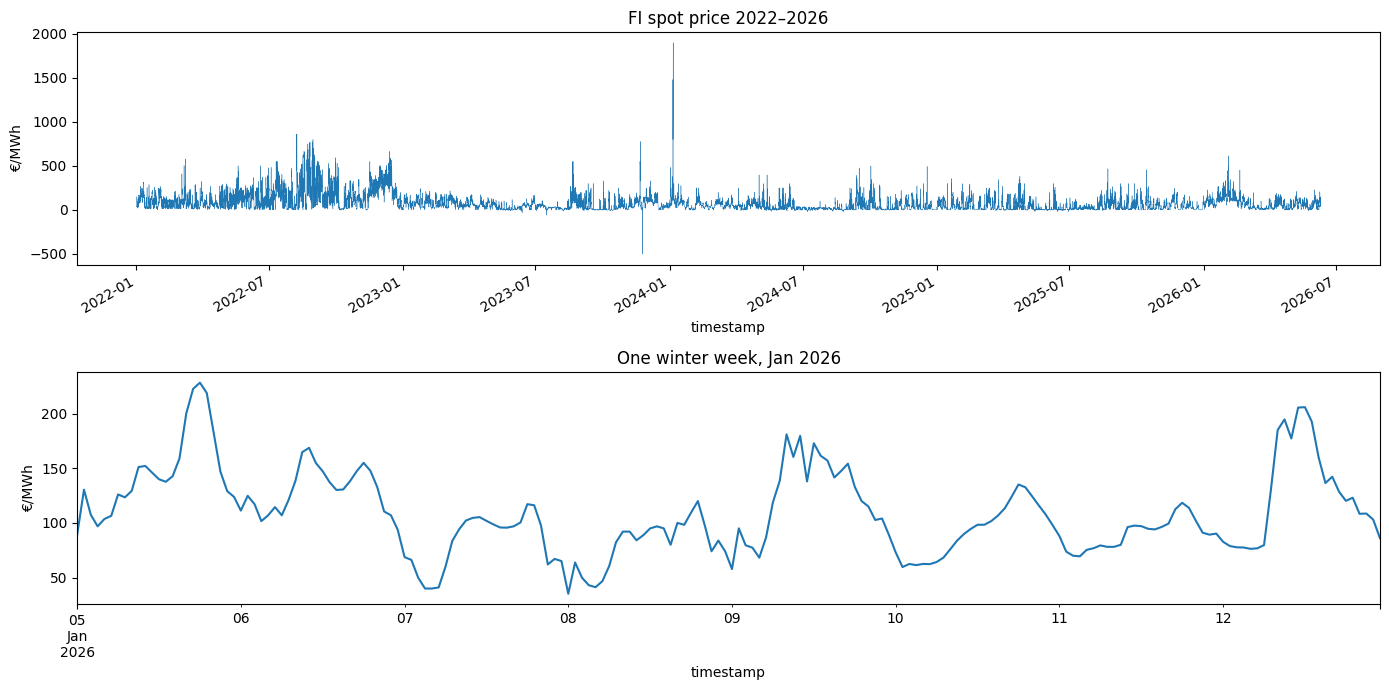

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
df_local["price_eur_mwh"].plot(ax=axes[0], lw=0.3, title="FI spot price 2022–2026")
axes[0].set_ylabel("€/MWh")
df_local.loc["2026-01-05":"2026-01-12", "price_eur_mwh"].plot(
    ax=axes[1], title="One winter week, Jan 2026")
axes[1].set_ylabel("€/MWh")
plt.tight_layout()

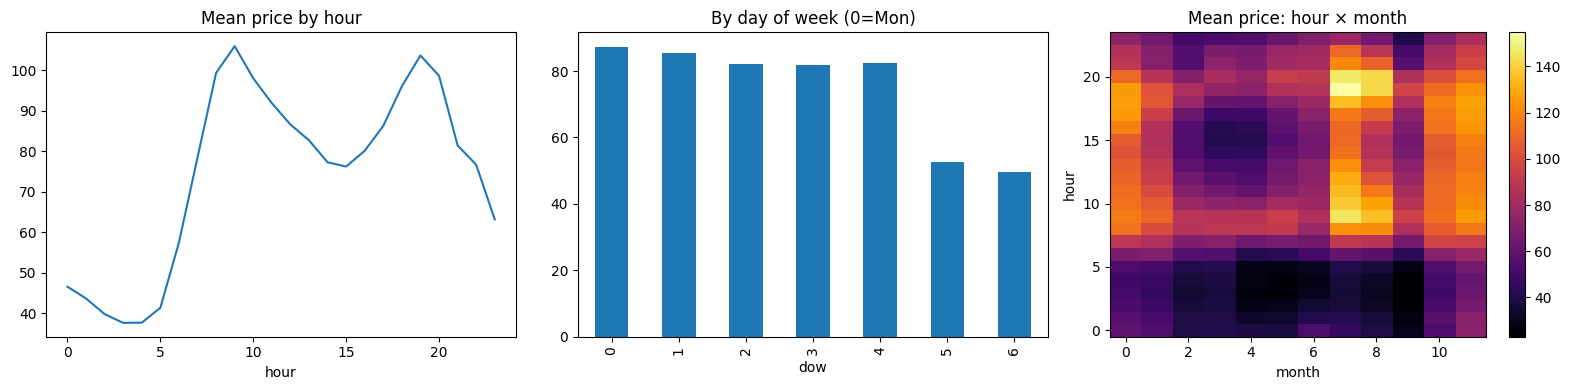

In [9]:
tmp = df_local.copy()
tmp["hour"] = tmp.index.hour
tmp["dow"] = tmp.index.dayofweek
tmp["month"] = tmp.index.month

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
tmp.groupby("hour")["price_eur_mwh"].mean().plot(ax=axes[0], title="Mean price by hour")
tmp.groupby("dow")["price_eur_mwh"].mean().plot(kind="bar", ax=axes[1], title="By day of week (0=Mon)")
pivot = tmp.pivot_table(values="price_eur_mwh", index="hour", columns="month", aggfunc="mean")
im = axes[2].imshow(pivot, aspect="auto", origin="lower", cmap="inferno")
axes[2].set_title("Mean price: hour × month")
axes[2].set_xlabel("month"); axes[2].set_ylabel("hour")
plt.colorbar(im, ax=axes[2])
plt.tight_layout()

(-100.0, 500.0)

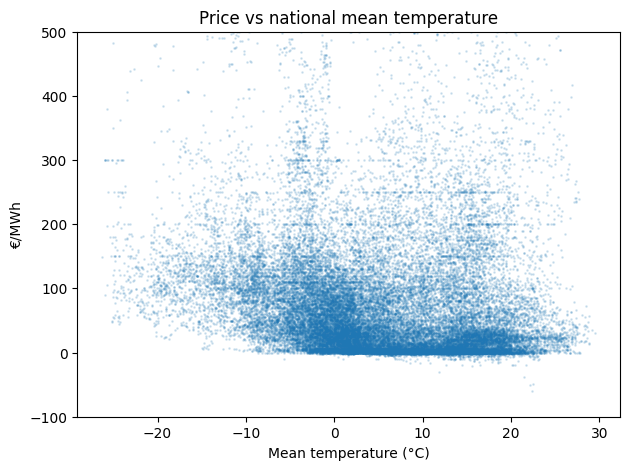

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df_local["temp_mean"], df_local["price_eur_mwh"], s=1, alpha=0.15)
ax.set_xlabel("Mean temperature (°C)"); ax.set_ylabel("€/MWh")
ax.set_title("Price vs national mean temperature")
ax.set_ylim(-100, 500)  # clipping the extreme spikes for readability

In [11]:
print(df["price_eur_mwh"].corr(df["temp_mean"]))
print(df["price_eur_mwh"].autocorr(24), df["price_eur_mwh"].autocorr(168))

-0.14417236786318563
0.681916788205008 0.5449971724472422


In [4]:
import holidays

fi_holidays = holidays.FI()

def build_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    local_idx = out.index.tz_convert("Europe/Helsinki")

    # Calendar features (local time)
    out["hour"] = local_idx.hour
    out["dow"] = local_idx.dayofweek
    out["month"] = local_idx.month
    out["is_weekend"] = (out["dow"] >= 5).astype(int)
    out["is_holiday"] = [int(d in fi_holidays) for d in local_idx.date]

    # Price lags: all >= 24h, so they're known at day-ahead bidding time
    p = out["price_eur_mwh"]
    out["lag_24"]  = p.shift(24)
    out["lag_48"]  = p.shift(48)
    out["lag_168"] = p.shift(168)

    # Rolling stats, shifted 24h so they only use known information
    out["roll_mean_24"]  = p.shift(24).rolling(24).mean()
    out["roll_std_24"]   = p.shift(24).rolling(24).std()
    out["roll_mean_168"] = p.shift(24).rolling(168).mean()

    # Weather: heating-degree style feature + raw temp
    out["hdd"] = (17.0 - out["temp_mean"]).clip(lower=0)  # heating degree hours

    return out.dropna()

feat = build_features(df)
print(feat.shape)
feat.columns.tolist()

(38608, 17)


['price_eur_mwh',
 'temp_helsinki',
 'temp_jyvaskyla',
 'temp_oulu',
 'temp_mean',
 'hour',
 'dow',
 'month',
 'is_weekend',
 'is_holiday',
 'lag_24',
 'lag_48',
 'lag_168',
 'roll_mean_24',
 'roll_std_24',
 'roll_mean_168',
 'hdd']

In [5]:
train = feat.loc[:"2024-12-31"]
val   = feat.loc["2025-01-01":"2025-12-31"]
test  = feat.loc["2026-01-01":]

print(f"Train: {len(train):>6} hours  {train.index.min().date()} → {train.index.max().date()}")
print(f"Val:   {len(val):>6} hours  {val.index.min().date()} → {val.index.max().date()}")
print(f"Test:  {len(test):>6} hours  {test.index.min().date()} → {test.index.max().date()}")

TARGET = "price_eur_mwh"
FEATURES = [c for c in feat.columns if c not in [TARGET]]
print(FEATURES)

Train:  26015 hours  2022-01-08 → 2024-12-31
Val:     8752 hours  2025-01-01 → 2025-12-31
Test:    3841 hours  2026-01-01 → 2026-06-10
['temp_helsinki', 'temp_jyvaskyla', 'temp_oulu', 'temp_mean', 'hour', 'dow', 'month', 'is_weekend', 'is_holiday', 'lag_24', 'lag_48', 'lag_168', 'roll_mean_24', 'roll_std_24', 'roll_mean_168', 'hdd']


In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name:<20} MAE: {mae:7.2f}   RMSE: {rmse:7.2f}  (€/MWh)")
    return {"model": name, "mae": mae, "rmse": rmse}

results = []

In [7]:
results.append(evaluate(val[TARGET], val["lag_24"],  "Naive (yesterday)"))
results.append(evaluate(val[TARGET], val["lag_168"], "Seasonal naive (-7d)"))

Naive (yesterday)    MAE:   35.93   RMSE:   57.82  (€/MWh)
Seasonal naive (-7d) MAE:   46.12   RMSE:   69.29  (€/MWh)


In [8]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

lgb_model.fit(
    train[FEATURES], train[TARGET],
    eval_set=[(val[FEATURES], val[TARGET])],
    eval_metric="mae",
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)],
)

val_pred_lgb = lgb_model.predict(val[FEATURES])
results.append(evaluate(val[TARGET], val_pred_lgb, "LightGBM"))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002611 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2853
[LightGBM] [Info] Number of data points in the train set: 26015, number of used features: 16
[LightGBM] [Info] Start training from score 85.303566
Training until validation scores don't improve for 100 rounds
[200]	valid_0's l1: 31.531	valid_0's l2: 2109.53
Early stopping, best iteration is:
[162]	valid_0's l1: 31.8579	valid_0's l2: 2102.71
LightGBM             MAE:   31.86   RMSE:   45.86  (€/MWh)


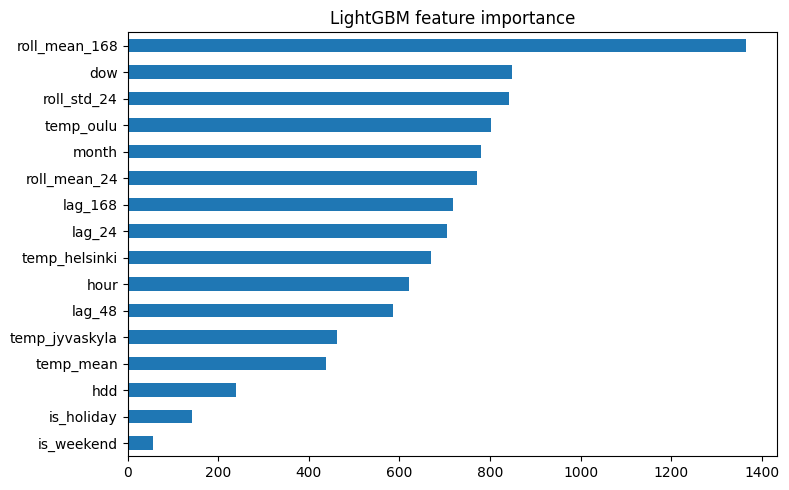

In [17]:
imp = pd.Series(lgb_model.feature_importances_, index=FEATURES).sort_values()
imp.plot(kind="barh", figsize=(8, 5), title="LightGBM feature importance")
plt.tight_layout()

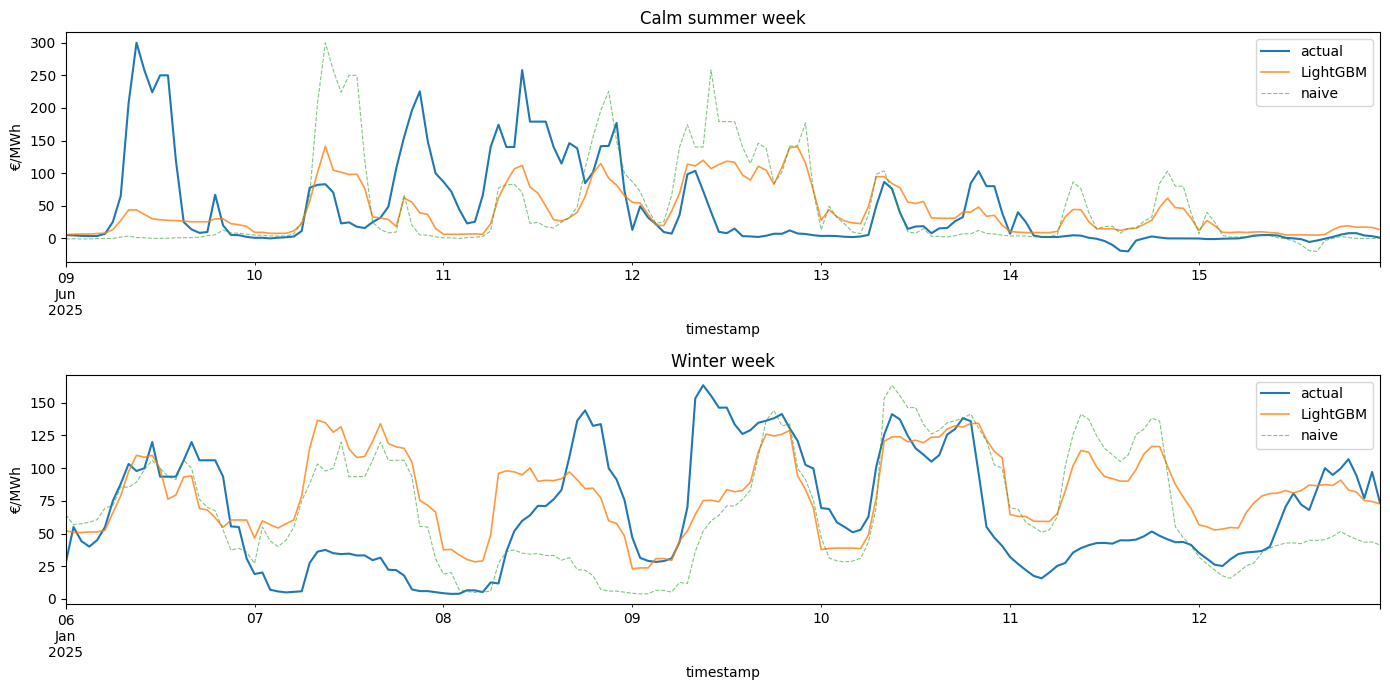

In [18]:
val_plot = val.copy()
val_plot["pred_lgb"] = val_pred_lgb
val_plot = val_plot.tz_convert("Europe/Helsinki")

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
for ax, window, title in [
    (axes[0], slice("2025-06-09", "2025-06-15"), "Calm summer week"),
    (axes[1], slice("2025-01-06", "2025-01-12"), "Winter week"),
]:
    val_plot.loc[window, TARGET].plot(ax=ax, label="actual", lw=1.5)
    val_plot.loc[window, "pred_lgb"].plot(ax=ax, label="LightGBM", lw=1.2, alpha=0.8)
    val_plot.loc[window, "lag_24"].plot(ax=ax, label="naive", lw=0.8, alpha=0.6, ls="--")
    ax.set_title(title); ax.legend(); ax.set_ylabel("€/MWh")
plt.tight_layout()

In [9]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)  # in Google Colab: CUDA

SEQ_LEN, HORIZON = 168, 24

# Scaling stats from TRAIN only
p_mu, p_sd = train[TARGET].mean(), train[TARGET].std()
t_mu, t_sd = train["temp_mean"].mean(), train["temp_mean"].std()

local_hours = feat.index.tz_convert(TZ).hour.values
arr = np.stack([
    (feat[TARGET].values - p_mu) / p_sd,
    (feat["temp_mean"].values - t_mu) / t_sd,
    np.sin(2 * np.pi * local_hours / 24),
    np.cos(2 * np.pi * local_hours / 24),
    feat.index.dayofweek.values / 6.0,
], axis=1).astype(np.float32)

price_scaled = arr[:, 0]
timestamps = feat.index

def make_windows(start_ts, end_ts, stride=1):
    """Windows whose 24h prediction target starts within [start_ts, end_ts]."""
    X, Y, target_starts = [], [], []
    for i in range(SEQ_LEN, len(arr) - HORIZON + 1, stride):
        t0 = timestamps[i]  # first predicted hour
        if start_ts <= t0 <= end_ts:
            X.append(arr[i - SEQ_LEN:i])
            Y.append(price_scaled[i:i + HORIZON])
            target_starts.append(i)
    return (torch.tensor(np.array(X)), torch.tensor(np.array(Y)), target_starts)

X_tr, Y_tr, _        = make_windows(pd.Timestamp("2022-01-15", tz="UTC"), pd.Timestamp("2024-12-31", tz="UTC"))
X_va, Y_va, va_idx   = make_windows(pd.Timestamp("2025-01-01", tz="UTC"), pd.Timestamp("2025-12-31", tz="UTC"), stride=24)
print(X_tr.shape, X_va.shape)   # expect roughly (25900, 168, 5) and (~364, 168, 5)

cuda
torch.Size([25824, 168, 5]) torch.Size([364, 168, 5])


In [10]:
class PriceLSTM(nn.Module):
    def __init__(self, n_features=5, hidden=128, layers=2, horizon=24):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, layers, batch_first=True, dropout=0.2)
        self.head = nn.Linear(hidden, horizon)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])   # last timestep's hidden state → 24 prices

model = PriceLSTM().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.L1Loss()   # MAE loss: robust to spikes, matches our metric

train_ds = torch.utils.data.TensorDataset(X_tr, Y_tr)
train_dl = torch.utils.data.DataLoader(train_ds, batch_size=256, shuffle=True)
X_va_d, Y_va_d = X_va.to(device), Y_va.to(device)

best_val, patience, bad_epochs = float("inf"), 8, 0
for epoch in range(60):
    model.train()
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        opt.step()

    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(X_va_d), Y_va_d).item()
    marker = ""
    if val_loss < best_val:
        best_val, bad_epochs = val_loss, 0
        torch.save(model.state_dict(), "lstm_best.pt")
        marker = " *"
    else:
        bad_epochs += 1
    print(f"epoch {epoch+1:2d}  val L1 (scaled): {val_loss:.4f}{marker}")
    if bad_epochs >= patience:
        print("Early stopping.")
        break

epoch  1  val L1 (scaled): 0.2613 *
epoch  2  val L1 (scaled): 0.2486 *
epoch  3  val L1 (scaled): 0.2516
epoch  4  val L1 (scaled): 0.2356 *
epoch  5  val L1 (scaled): 0.2368
epoch  6  val L1 (scaled): 0.2323 *
epoch  7  val L1 (scaled): 0.2291 *
epoch  8  val L1 (scaled): 0.2269 *
epoch  9  val L1 (scaled): 0.2258 *
epoch 10  val L1 (scaled): 0.2270
epoch 11  val L1 (scaled): 0.2251 *
epoch 12  val L1 (scaled): 0.2225 *
epoch 13  val L1 (scaled): 0.2226
epoch 14  val L1 (scaled): 0.2289
epoch 15  val L1 (scaled): 0.2303
epoch 16  val L1 (scaled): 0.2284
epoch 17  val L1 (scaled): 0.2391
epoch 18  val L1 (scaled): 0.2320
epoch 19  val L1 (scaled): 0.2379
epoch 20  val L1 (scaled): 0.2336
Early stopping.


In [11]:
model.load_state_dict(torch.load("lstm_best.pt"))
model.eval()
with torch.no_grad():
    pred_scaled = model(X_va_d).cpu().numpy()

# Flatten back into an hourly series
pred_lstm = pd.Series(
    (pred_scaled * p_sd + p_mu).ravel(),
    index=pd.DatetimeIndex(np.concatenate(
        [timestamps[i:i + HORIZON] for i in va_idx]))
)

common = pred_lstm.index.intersection(val.index)
results.append(evaluate(val.loc[common, TARGET], pred_lstm.loc[common], "LSTM"))

LSTM                 MAE:   23.55   RMSE:   38.68  (€/MWh)


MAE hours 1–12:  21.65
MAE hours 13–24: 25.45


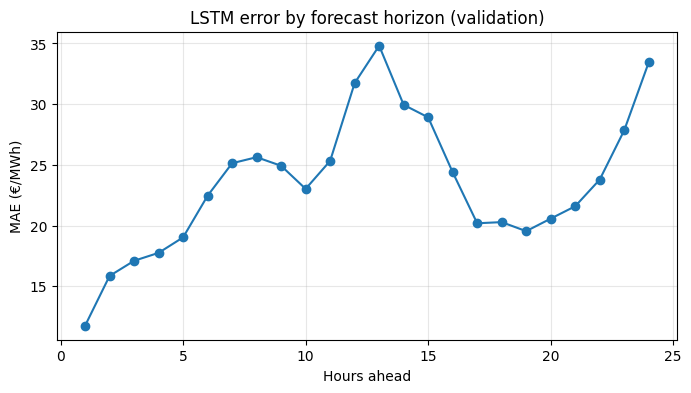

In [12]:
with torch.no_grad():
    pred_scaled = model(X_va_d).cpu().numpy()
errs = np.abs(pred_scaled * p_sd - (Y_va.numpy() * p_sd))   # €/MWh, per window per step

per_horizon = errs.mean(axis=0)
plt.figure(figsize=(8, 4))
plt.plot(range(1, 25), per_horizon, marker="o")
plt.xlabel("Hours ahead"); plt.ylabel("MAE (€/MWh)")
plt.title("LSTM error by forecast horizon (validation)")
plt.grid(alpha=0.3)
print(f"MAE hours 1–12:  {errs[:, :12].mean():.2f}")
print(f"MAE hours 13–24: {errs[:, 12:].mean():.2f}")

In [13]:
final = []

# Baselines
final.append(evaluate(test[TARGET], test["lag_24"],  "Naive (yesterday)"))
final.append(evaluate(test[TARGET], test["lag_168"], "Seasonal naive (-7d)"))

# LightGBM
test_pred_lgb = lgb_model.predict(test[FEATURES])
final.append(evaluate(test[TARGET], test_pred_lgb, "LightGBM"))

# LSTM: daily forecast runs over the test period
X_te, Y_te, te_idx = make_windows(
    pd.Timestamp("2026-01-01", tz="UTC"),
    pd.Timestamp("2026-06-10", tz="UTC"), stride=24)
with torch.no_grad():
    te_pred_scaled = model(X_te.to(device)).cpu().numpy()

pred_lstm_test = pd.Series(
    (te_pred_scaled * p_sd + p_mu).ravel(),
    index=pd.DatetimeIndex(np.concatenate([timestamps[i:i + HORIZON] for i in te_idx])))

common = pred_lstm_test.index.intersection(test.index)
final.append(evaluate(test.loc[common, TARGET], pred_lstm_test.loc[common], "LSTM"))

pd.DataFrame(final).set_index("model").round(2)

Naive (yesterday)    MAE:   35.16   RMSE:   52.77  (€/MWh)
Seasonal naive (-7d) MAE:   48.47   RMSE:   65.56  (€/MWh)
LightGBM             MAE:   31.50   RMSE:   45.33  (€/MWh)
LSTM                 MAE:   25.41   RMSE:   40.18  (€/MWh)


,mae,rmse
model,,
Naive (yesterday),35.16,52.77
Seasonal naive (-7d),48.47,65.56
LightGBM,31.50,45.33
LSTM,25.41,40.18


In [14]:
train_2023 = train.loc["2023-01-01":]
lgb_recent = lgb.LGBMRegressor(
    n_estimators=2000, learning_rate=0.03, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, random_state=42)
lgb_recent.fit(train_2023[FEATURES], train_2023[TARGET],
               eval_set=[(val[FEATURES], val[TARGET])],
               eval_metric="mae", callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)])
final.append(evaluate(test[TARGET], lgb_recent.predict(test[FEATURES]), "LightGBM (2023+)"))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001027 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2853
[LightGBM] [Info] Number of data points in the train set: 17446, number of used features: 16
[LightGBM] [Info] Start training from score 51.180417
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[97]	valid_0's l1: 31.7578	valid_0's l2: 2063.71
LightGBM (2023+)     MAE:   34.16   RMSE:   51.24  (€/MWh)


Text(0.5, 1.0, 'Test set: winter week, Jan 2026')

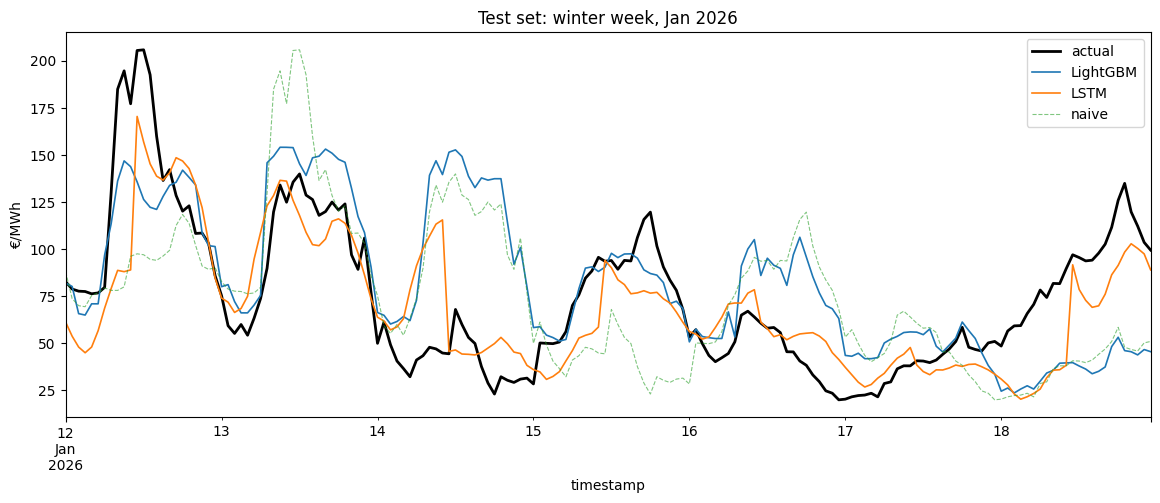

In [15]:
plot_df = test.copy().tz_convert(TZ)
plot_df["LightGBM"] = test_pred_lgb
plot_df = plot_df.join(pred_lstm_test.rename("LSTM").tz_convert(TZ))

week = plot_df.loc["2026-01-12":"2026-01-18"]
fig, ax = plt.subplots(figsize=(14, 5))
week[TARGET].plot(ax=ax, label="actual", lw=2, color="black")
week["LightGBM"].plot(ax=ax, label="LightGBM", lw=1.2)
week["LSTM"].plot(ax=ax, label="LSTM", lw=1.2)
week["lag_24"].plot(ax=ax, label="naive", lw=0.8, ls="--", alpha=0.6)
ax.legend(); ax.set_ylabel("€/MWh"); ax.set_title("Test set: winter week, Jan 2026")